In [1]:
from pathlib import Path

folder = Path("/mnt/data/datasets/Сравнение чертежей/Эскизы датасет")
files = sorted(folder.glob("*.jpg"))

for i, file in enumerate(files):
    print(f"[{i}] {file.stem}")

[0] 1
[1] 10
[2] 11
[3] 12
[4] 13
[5] 14
[6] 15
[7] 16
[8] 17
[9] 18
[10] 19
[11] 2
[12] 20
[13] 21
[14] 3
[15] 4
[16] 5
[17] 6
[18] 7
[19] 8
[20] 9


In [2]:
IDX = 2

In [3]:
import cv2

img_bgr = cv2.imread(str(files[IDX]), cv2.IMREAD_COLOR_BGR)

In [4]:
INCH_2_CM = 2.54


def rescale_image(image, long_side_mm, dpi):
    """
    Нормализует изображение так, чтобы его длинная сторона
    соответствовала заданному физическому размеру в мм.
    Работает корректно и для Portrait, и для Landscape.
    """
    if image is None:
        return None

    # 1. Рассчитываем целевой размер длинной стороны в пикселях
    # Используем round(), чтобы минимизировать погрешность float
    pixels_per_mm = dpi / (INCH_2_CM * 10)
    target_long_side_px = round(long_side_mm * pixels_per_mm)

    # 2. Получаем текущие размеры
    h, w = image.shape[:2]
    current_long_side_px = max(h, w)

    # Защита от деления на ноль, если картинка повреждена
    if current_long_side_px == 0:
        return image

    # 3. Вычисляем точный коэффициент масштабирования
    scale_ratio = target_long_side_px / float(current_long_side_px)

    # 4. Вычисляем новые размеры, жестко фиксируя целевую сторону
    if w >= h:  # Landscape
        new_w = target_long_side_px
        new_h = round(h * scale_ratio)
    else:  # Portrait
        new_h = target_long_side_px
        new_w = round(w * scale_ratio)

    # 5. Выбираем метод интерполяции
    interpolation = cv2.INTER_LANCZOS4 if scale_ratio > 1 else cv2.INTER_AREA

    # 6. Ресайз
    return cv2.resize(image, (new_w, new_h), interpolation=interpolation)

In [5]:
for f in files:
    img = cv2.imread(str(f), cv2.IMREAD_COLOR_BGR)
    h, w = img.shape[:2]
    resize_img = rescale_image(img, 210, 300)
    rh, rw = resize_img.shape[:2]
    print(f"width: {w} height {h} scale: {(h / w):2f} -> w: {rw}  h{rh}   scale: {(rh / rw):2f}")

width: 1085 height 518 scale: 0.477419 -> w: 2480  h1184   scale: 0.477419
width: 1085 height 518 scale: 0.477419 -> w: 2480  h1184   scale: 0.477419
width: 1421 height 885 scale: 0.622801 -> w: 2480  h1545   scale: 0.622984
width: 1431 height 907 scale: 0.633823 -> w: 2480  h1572   scale: 0.633871
width: 6812 height 3321 scale: 0.487522 -> w: 2480  h1209   scale: 0.487500
width: 6819 height 3378 scale: 0.495381 -> w: 2480  h1229   scale: 0.495565
width: 1475 height 919 scale: 0.623051 -> w: 2480  h1545   scale: 0.622984
width: 1475 height 919 scale: 0.623051 -> w: 2480  h1545   scale: 0.622984
width: 1085 height 518 scale: 0.477419 -> w: 2480  h1184   scale: 0.477419
width: 4102 height 2152 scale: 0.524622 -> w: 2480  h1301   scale: 0.524597
width: 1158 height 622 scale: 0.537133 -> w: 2480  h1332   scale: 0.537097
width: 1085 height 518 scale: 0.477419 -> w: 2480  h1184   scale: 0.477419
width: 9239 height 5786 scale: 0.626258 -> w: 2480  h1553   scale: 0.626210
width: 9239 height 57

In [6]:
import numpy as np

# https://raw.githubusercontent.com/PaddlePaddle/PaddleOCR/main/ppocr/data/imaug/operators.py


def preprocess_detector(src_bgr: np.ndarray) -> tuple[np.ndarray, float, float]:
    """
    Препроцессинг для PaddleOCR (DBNet) ONNX.

    Args:
        src_bgr: Исходное изображение в формате BGR (cv2).

    Returns:
        blob: Подготовленный тензор (1, 3, H, W)
        ratio_w: Коэффициент масштабирования по ширине (для постпроцессинга)
        ratio_h: Коэффициент масштабирования по высоте (для постпроцессинга)
    """
    h, w = src_bgr.shape[:2]

    # 1. ВАЖНО: PaddleOCR обучался на RGB. OpenCV читает в BGR.
    img = cv2.cvtColor(src_bgr, cv2.COLOR_BGR2RGB)

    # 2. Расчет размеров, кратных 32.
    # Вместо round лучше использовать ceil (округление вверх),
    # чтобы не уменьшать картинку слишком сильно, что может "сжать" мелкий текст.
    resize_w = int(np.ceil(w / 32.0) * 32)
    resize_h = int(np.ceil(h / 32.0) * 32)

    # Ограничение минимального размера (чтобы не было 0)
    resize_w = max(resize_w, 32)
    resize_h = max(resize_h, 32)

    # 3. Ресайз.
    # Используем INTER_LINEAR для масштабирования вверх и INTER_AREA для вниз.
    if resize_w < w or resize_h < h:
        interp = cv2.INTER_AREA
    else:
        interp = cv2.INTER_LINEAR

    resized = cv2.resize(img, (resize_w, resize_h), interpolation=interp)

    # 4. Нормализация.
    # ВНИМАНИЕ: Стандартные модели PaddleOCR (DBNet) обычно используют
    # нормализацию (x/255 - 0.5) / 0.5, а не ImageNet mean/std.
    # Если вы уверены, что ваша модель использует ImageNet, оставьте как было.
    # Но для 99% моделей PaddleOCR используйте этот вариант:
    blob = (resized.astype(np.float32) / 255.0 - 0.5) / 0.5

    # Перестановка осей из HWC -> CHW и добавление Batch dimension
    blob = blob.transpose(2, 0, 1)[np.newaxis, ...]

    # 5. Возвращаем коэффициенты для постпроцессинга!
    # Без них вы не сможете правильно вернуть координаты боксов на оригинал.
    ratio_w = w / resize_w
    ratio_h = h / resize_h

    return blob, ratio_w, ratio_h


In [7]:
import onnxruntime as ort

det_model_path = "./models/PP-OCRv5_server_det_infer.onnx"
det_session = ort.InferenceSession(det_model_path)

In [8]:
resize_img = rescale_image(img_bgr, 210, 100)
blob, r_w, r_h = preprocess_detector(resize_img)
blob.shape

(1, 3, 544, 832)

In [9]:
print(det_session.get_inputs()[0].name)

x


In [10]:
output = det_session.run(None, {"x": blob})[0]

In [11]:
mask_probs = output[0, 0]
threshold = 0.3
binary_mask = (mask_probs > threshold).astype(np.uint8)
binary_mask.shape

(544, 832)

In [12]:
_h, _w = resize_img.shape[:2]
binary_mask = cv2.resize(binary_mask, (_w, _h))
binary_mask.shape
# (410, 827)

(515, 827)

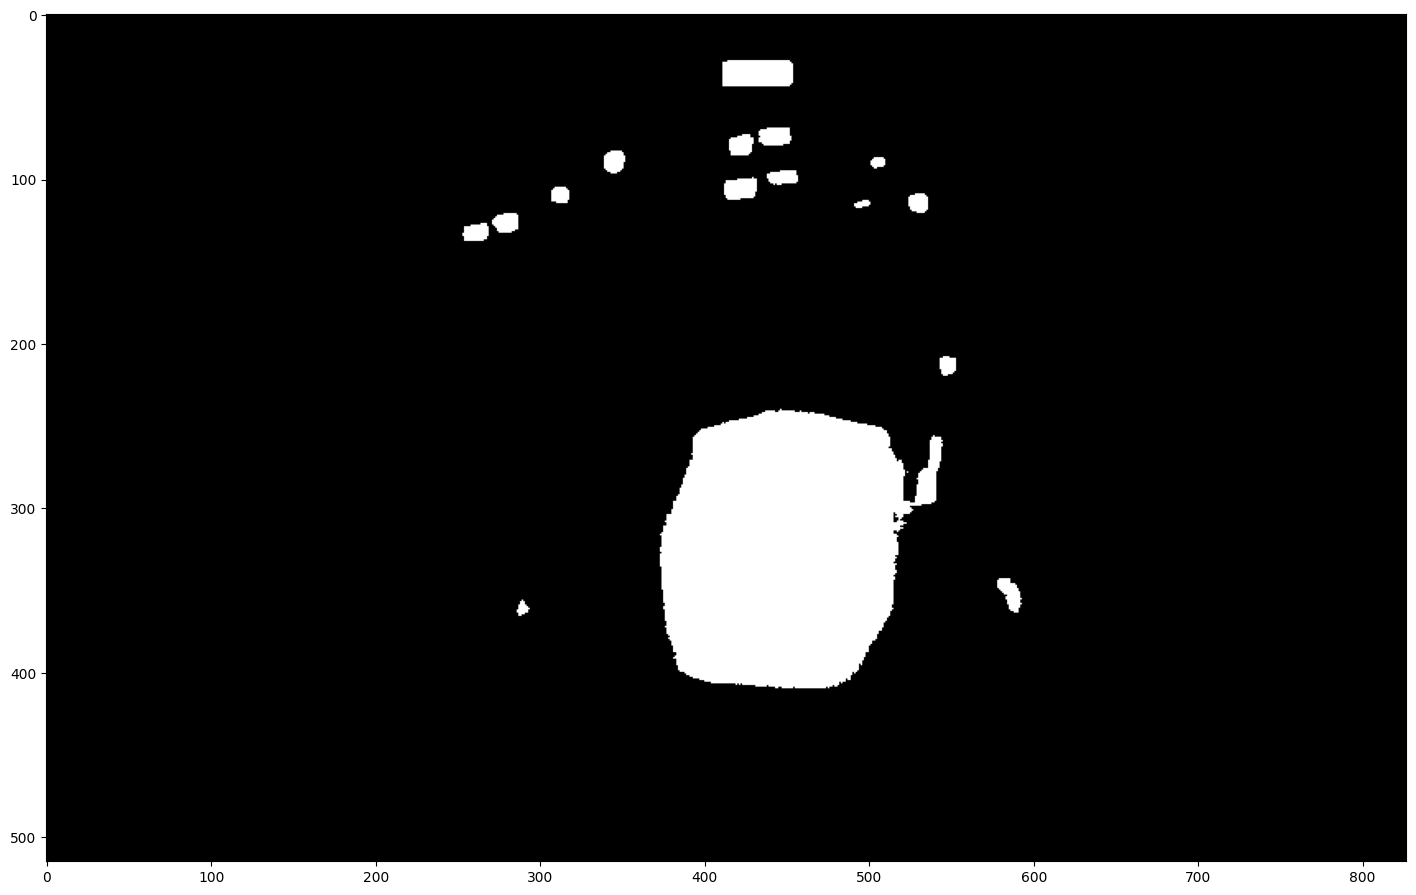

In [13]:
from matplotlib import pyplot as plt

plt.figure(figsize=(18, 11))
plt.imshow(binary_mask, cmap="gray")
plt.show()

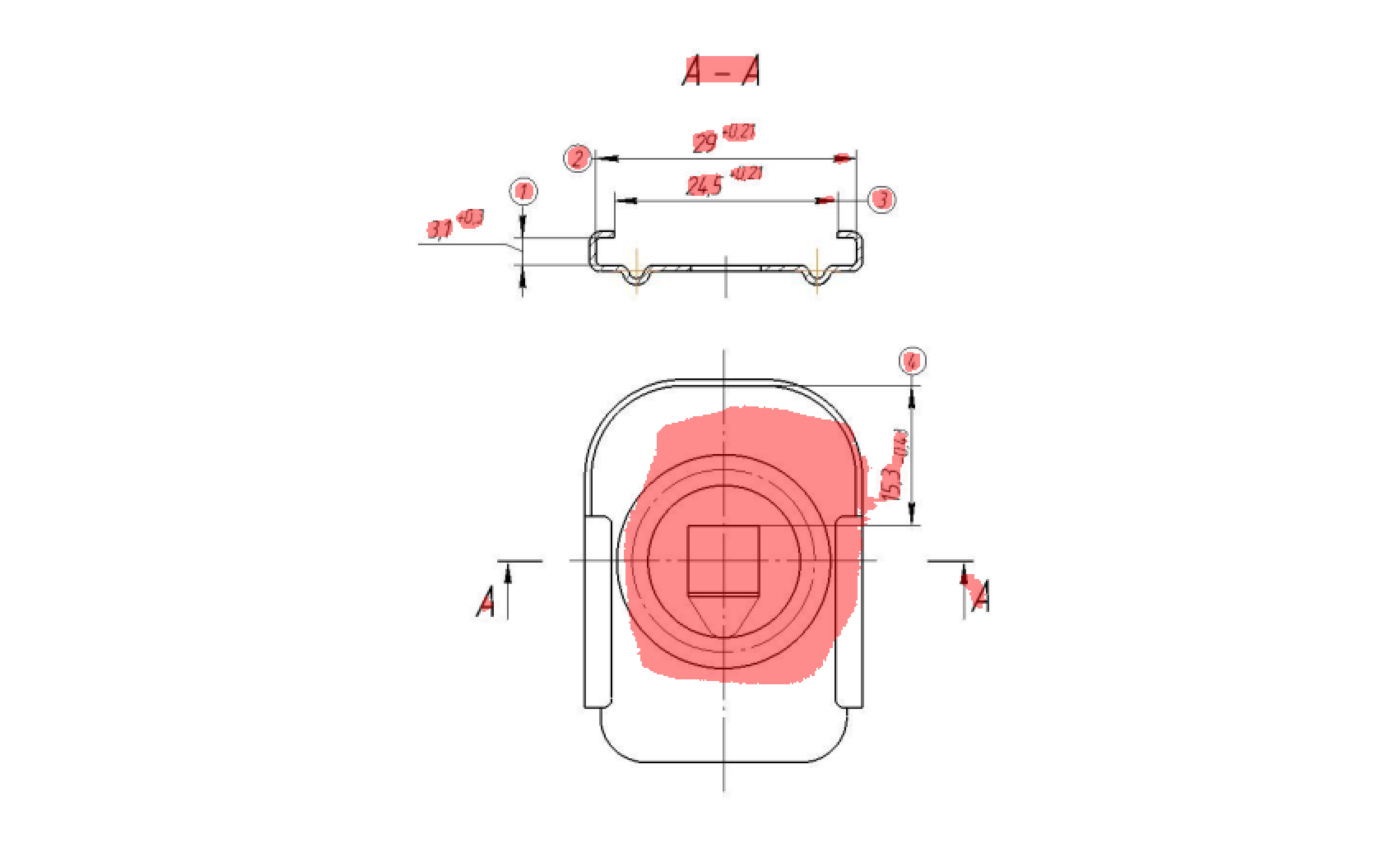

In [14]:
vis_text = resize_img.copy()

vis_text[binary_mask > 0] = (0, 0, 255)
blend = cv2.addWeighted(vis_text, 0.45, resize_img, 0.55, 0)

plt.figure(figsize=(18, 11))
plt.imshow(blend[:, :, ::-1])
plt.axis("off")
plt.show()

In [15]:
img_300dpi = rescale_image(img_bgr, 210, 300)

base_h, base_w = img_300dpi.shape[:2]

dpis = [75, 150, 300]
threshold = 0.3
# Аккумулятор должен быть размером с оригинальным изображение
acc = np.zeros((base_h, base_w), dtype=np.float32)
count = 0

for dpi in dpis:
    # 1. Создаем изображение для текущего DPI
    # (Предполагаю, что rescale_image возвращает новую картинку)
    if dpi == 300:
        current_res_img = img_300dpi
    else:
        current_res_img = rescale_image(img_300dpi, 210, dpi)

    # 2. Препроцессинг (ВАЖНО: передаем current_res_img!)
    blob, r_w, r_h = preprocess_detector(current_res_img)

    # 3. Инференс
    output = det_session.run(None, {"x": blob})[0]
    mask_probs = output[0, 0]
    # 4. Ресайз маски обратно к размеру ОРИГИНАЛЬНОГО изображения
    # Мы берем вероятности (float) и растягиваем их до размера base_w, base_h
    # Это позволит нам суммировать маски разных разрешений
    mask_resized = cv2.resize(mask_probs, (base_w, base_h), interpolation=cv2.INTER_LINEAR)

    # 5. Накапливаем вероятности
    acc += mask_resized
    count += 1
acc /= count

In [16]:
# Базовый порог для перевода вероятностей в бинарную маску
bin_threshold = 0.3
# Порог средней уверенности внутри контура (должен быть выше bin_threshold)
box_score_threshold = 0.4

# 1. Первичная бинаризация аккумулятора
binary_acc = (acc > bin_threshold).astype(np.uint8) * 255

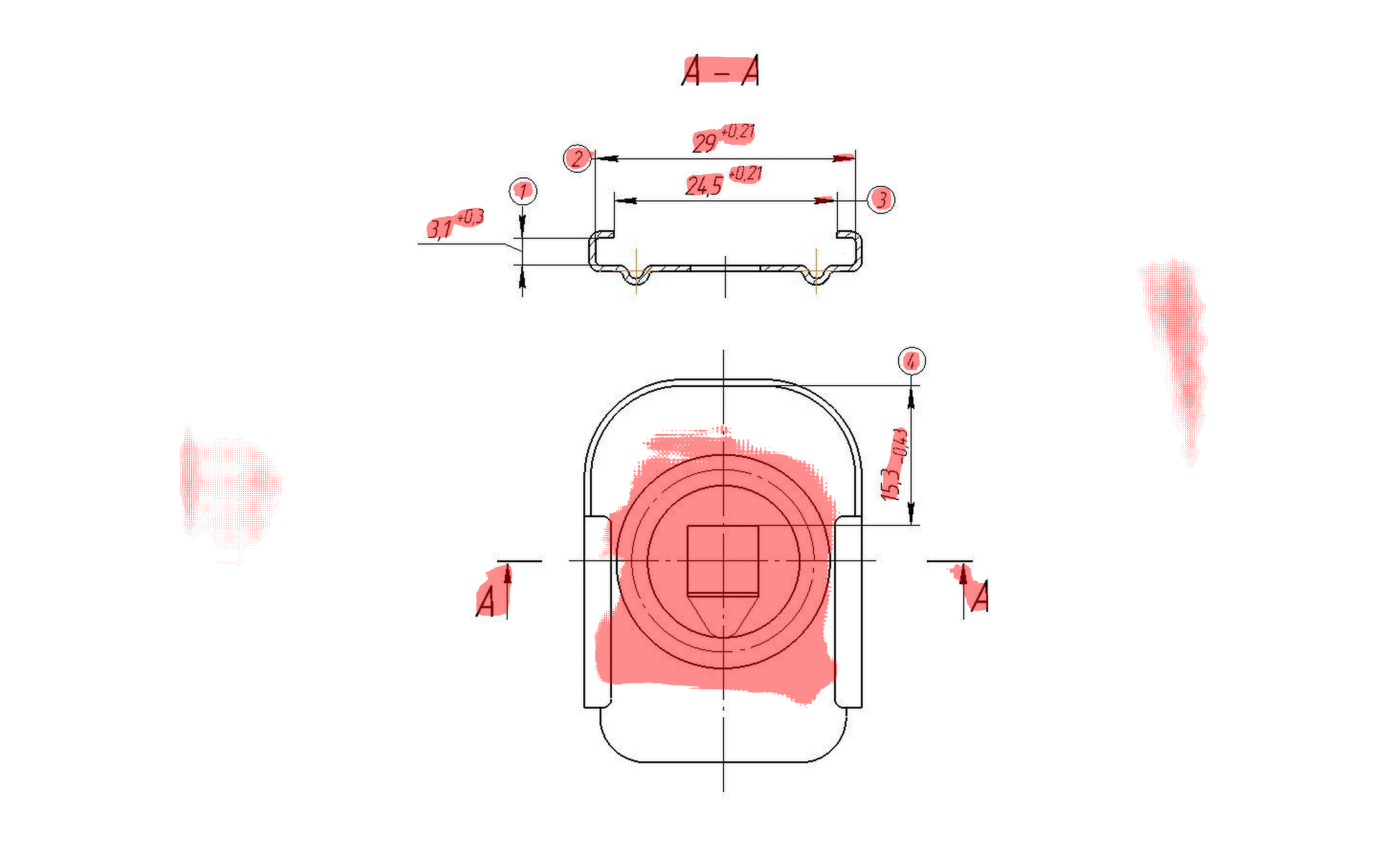

In [17]:
vis_text = img_300dpi.copy()

vis_text[binary_acc > 0] = (0, 0, 255)
blend = cv2.addWeighted(vis_text, 0.45, img_300dpi, 0.55, 0)

plt.figure(figsize=(18, 11))
plt.imshow(blend[:, :, ::-1])
plt.axis("off")
plt.show()

In [18]:
def geometric_unclip_mask_precise(raw_pred_mask: np.ndarray, ratio: float = 1.5) -> np.ndarray:
    """
    Геометрическое расширение маски с сохранением формы контура.
    Избегает эффекта "квадрата" (minAreaRect) и "мыла" (dilate).
    """
    # Создаем пустую маску для результата
    geom_unclip_mask = np.zeros(raw_pred_mask.shape, dtype=np.uint8)

    # 1. Ищем реальные контуры (не прямоугольники!)
    cnts, _ = cv2.findContours(raw_pred_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for c in cnts:
        if len(c) < 3:
            continue

        area = cv2.contourArea(c)
        perimeter = cv2.arcLength(c, True)
        if perimeter == 0:
            continue

        # Твоя формула для вычисления "радиуса" расширения
        # Она определяет, на сколько пикселей мы "вырастим" контур
        distance = (area * ratio) / perimeter

        # Ограничиваем expansion_dist, чтобы не захватить пол-чертежа
        # (Настрой эти значения под свое разрешение/DPI)
        expansion_dist = max(2, min(int(distance), 15))

        # 2. Рисуем текущий контур в отдельную временную маску
        temp_mask = np.zeros(raw_pred_mask.shape, dtype=np.uint8)
        cv2.drawContours(temp_mask, [c], -1, 255, thickness=cv2.FILLED)

        # 3. ХИТРЫЙ ШАГ: Дистанционное преобразование
        # Мы инвертируем маску: 0 — это текст, 255 — фон
        inv_mask = cv2.bitwise_not(temp_mask)

        # dist_map содержит расстояние от каждого пикселя фона до ближайшего пикселя текста
        dist_map = cv2.distanceTransform(inv_mask, cv2.DIST_L2, 5)

        # 4. Захватываем область вокруг контура
        # Все пиксели, расстояние до которых <= expansion_dist, становятся частью маски
        # Это и есть наше "геометрическое расширение" без создания квадратов
        expanded_region = (dist_map <= expansion_dist).astype(np.uint8) * 255

        # Объединяем оригинальный контур и расширенную область
        # (чтобы не было дырок внутри самой буквы)
        combined_contour_mask = cv2.bitwise_or(temp_mask, expanded_region)

        # Добавляем в общую маску
        cv2.bitwise_or(geom_unclip_mask, combined_contour_mask, geom_unclip_mask)

    return geom_unclip_mask


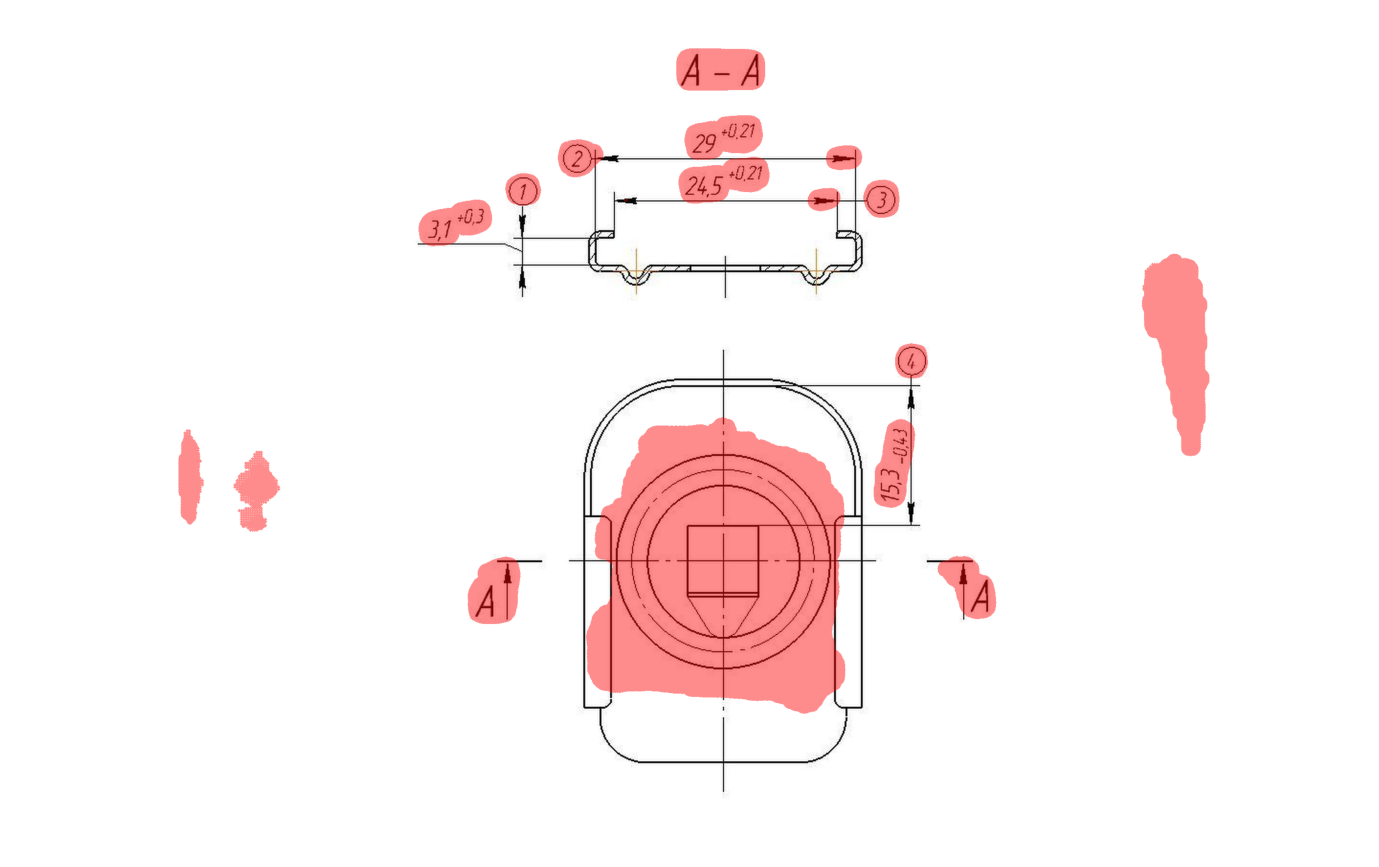

In [19]:
_geom_mask = geometric_unclip_mask_precise(binary_acc, ratio=15.5)

vis_text_unclip = img_300dpi.copy()

vis_text_unclip[_geom_mask > 0] = (0, 0, 255)
blend = cv2.addWeighted(vis_text_unclip, 0.45, img_300dpi, 0.55, 0)

plt.figure(figsize=(18, 11))
plt.imshow(blend[:, :, ::-1])
plt.axis("off")
plt.show()

In [20]:
# 2. Поиск контуров
cnts, _ = cv2.findContours(_geom_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

clean_pred_mask = np.zeros_like(_geom_mask)

for c in cnts:
    area = cv2.contourArea(c)
    if area < 20:
        continue

    # 1. Проверка на Aspect Ratio (у тебя уже есть)
    rect = cv2.minAreaRect(c)
    (cx, cy), (w, h), angle = rect
    if min(w, h) == 0:
        continue
    aspect_ratio = max(w, h) / min(w, h)
    if aspect_ratio > 30:
        continue

    # 2. Проверка на Solidity (Критически важно для "хвостов" и линий)
    hull = cv2.convexHull(c)
    hull_area = cv2.contourArea(hull)
    if hull_area == 0:
        continue
    solidity = area / hull_area

    # Текст обычно имеет solidity > 0.5.
    # Линия или очень тонкий хвост будут иметь очень низкую solidity.
    if solidity < 0.4:
        continue

    # 3. Проверка на Compactness
    perimeter = cv2.arcLength(c, True)
    if perimeter == 0:
        continue
    compactness = (perimeter**2) / area
    # У линий compactness будет очень высоким (они почти одномерны)
    # Но здесь лучше использовать логику: если объект слишком "вытянут" - это линия.
    # (Aspect Ratio уже частично это делает)

    # Если прошел все фильтры
    cv2.fillPoly(clean_pred_mask, [c.astype(np.int32)], 255)


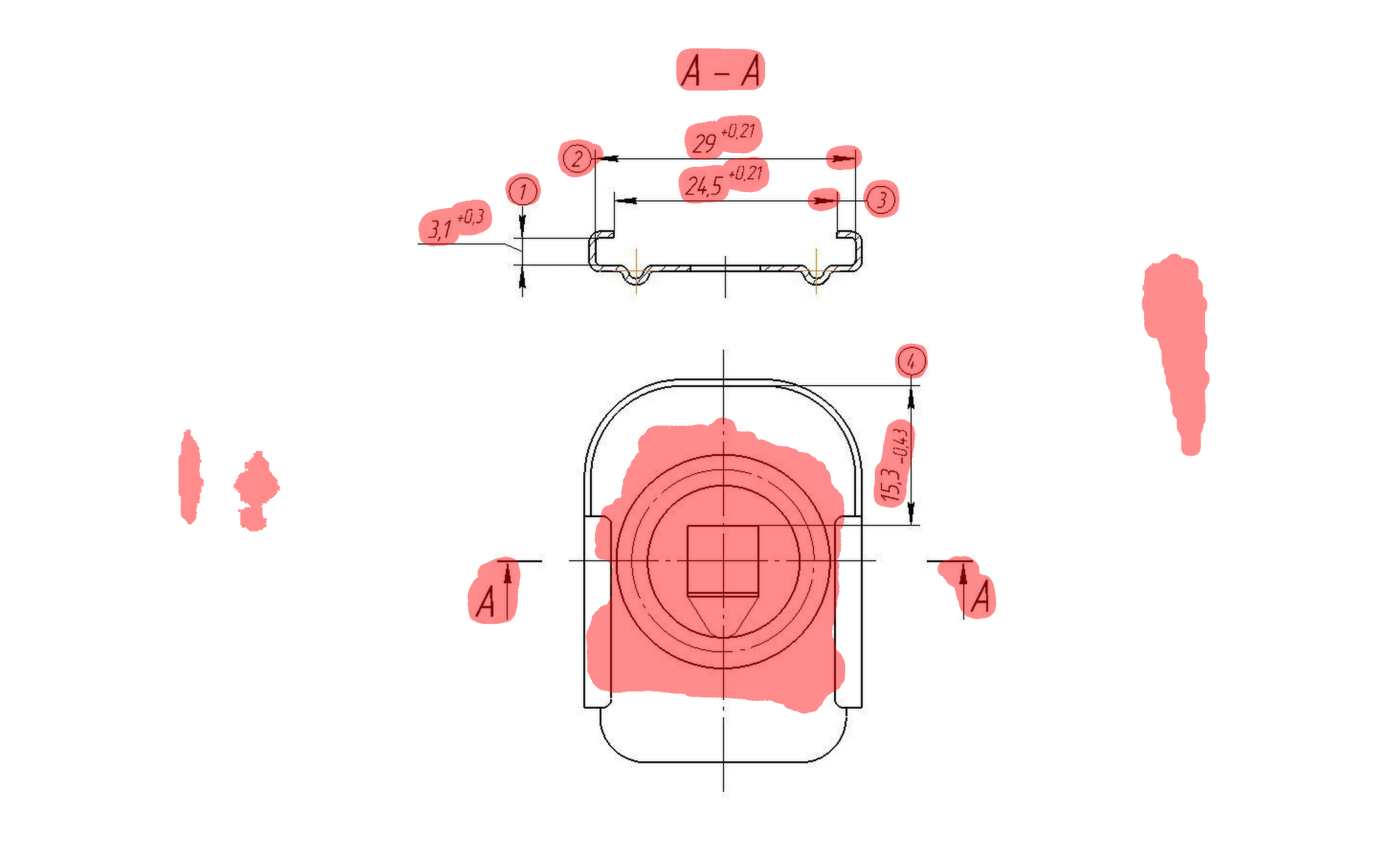

In [21]:
vis_text = img_300dpi.copy()

vis_text[clean_pred_mask > 0] = (0, 0, 255)
blend = cv2.addWeighted(vis_text, 0.45, img_300dpi, 0.55, 0)

plt.figure(figsize=(18, 11))
plt.imshow(blend[:, :, ::-1])
plt.axis("off")
plt.show()

In [22]:
import cv2
import numpy as np


def capture_text_with_tails(
    binary_drawing: np.ndarray,
    clean_pred_mask: np.ndarray,
    dilation_kernel_size: int = 5,
    iterations: int = 2,
) -> np.ndarray:
    """
    Захватывает точные пиксели текста вместе с хвостами,
    отсекая длинные линии геометрии чертежа.
    """

    # 1. Расширяем чистую маску OCR.
    # Морфологическое ядро в форме эллипса плавно "раздует" маску во все стороны.
    # Размер 5x5 в 2 итерации добавит примерно 4-5 пикселей к границам красных зон,
    # что идеально для захвата хвостов из image_6375b0.jpg.
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (dilation_kernel_size, dilation_kernel_size))
    expanded_mask = cv2.dilate(clean_pred_mask, kernel, iterations=iterations)

    # 2. ГЛАВНЫЙ ШАГ: Накладываем расширенную маску на исходный бинарник.
    # Если длинная линия выноски пересекала текст, теперь от нее останется
    # только крошечный обрезок (хвостик), попавший внутрь expanded_mask.
    local_pixels = cv2.bitwise_and(binary_drawing, expanded_mask)

    # 3. Финальная фильтрация компонентов внутри локальной зоны.
    # Теперь мы ищем компоненты только на "вырезанных" пикселях.
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(local_pixels, connectivity=8)

    final_text_pixels = np.zeros_like(binary_drawing)

    for label in range(1, num_labels):
        area = stats[label, cv2.CC_STAT_AREA]

        # Точка, запятая или оторванный хвост буквы могут быть маленькими,
        # поэтому отсекаем только абсолютный мусор (меньше 3-5 пикселей).
        if area > 4:
            final_text_pixels[labels == label] = 255

    return final_text_pixels


In [23]:
def filter_by_components(
    binary_image: np.ndarray, geom_unclip_mask: np.ndarray, max_char_size: int = 100
) -> np.ndarray:
    """
    Фильтрует исходный чертеж, оставляя только компоненты,
    которые одновременно:
    1. Маленькие (не линии/рамки).
    2. Находятся в области, предсказанной детекторами (geom_unclip_mask).
    """

    final_text_mask = np.zeros_like(binary_image)

    # 1. Находим все компоненты в исходном чертеже
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_image, connectivity=8)

    for label in range(1, num_labels):
        w = stats[label, cv2.CC_STAT_WIDTH]
        h = stats[label, cv2.CC_STAT_HEIGHT]

        # Защитный фильтр: Пропускаем компоненты, слишком большие (линии, рамки).
        if w > max_char_size and h > max_char_size:
            continue

        component_mask = labels == label

        # 2. Проверка пересечения: Находится ли компонент в расширенной области?
        # Проверяем, есть ли пиксели компонента в маске геометрического unclip
        if np.any(geom_unclip_mask[component_mask] > 0):
            # 3. Переносим пиксели компонента на финальную маску,
            # но только если они прошли проверку overlap (перекрытие с expanded mask).
            final_text_mask[component_mask] = 255

    return final_text_mask

In [24]:
gray = cv2.cvtColor(img_300dpi, cv2.COLOR_BGR2GRAY)
_, binary_drawing = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)

In [25]:
_geom_mask = capture_text_with_tails(
    binary_drawing=binary_drawing,
    clean_pred_mask=clean_pred_mask,
    dilation_kernel_size=5,
    iterations=1,
)


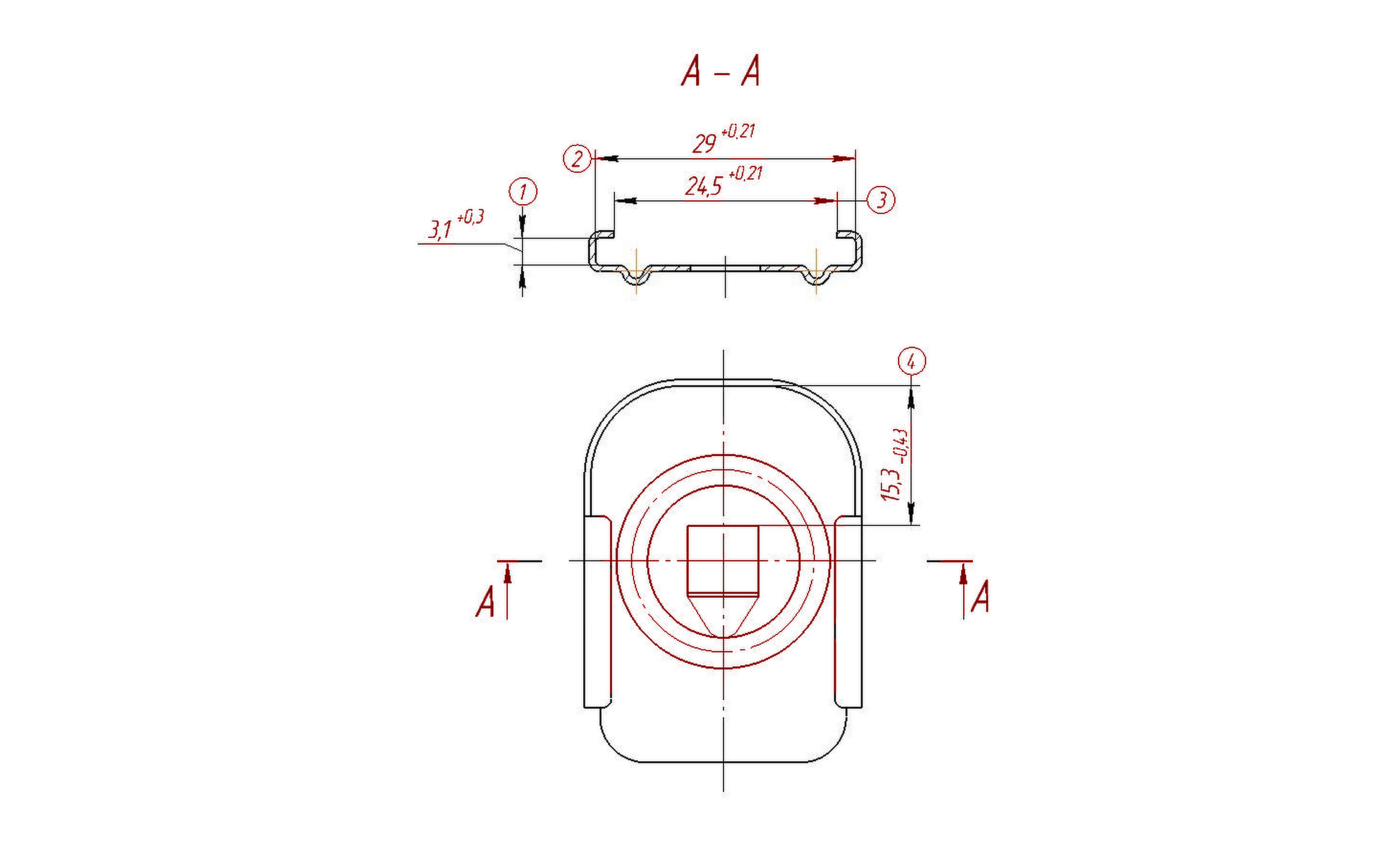

In [26]:
vis_text = img_300dpi.copy()

vis_text[_geom_mask > 0] = (0, 0, 255)
blend = cv2.addWeighted(vis_text, 0.45, img_300dpi, 0.55, 0)

plt.figure(figsize=(18, 11))
plt.imshow(blend[:, :, ::-1])
plt.axis("off")
plt.show()

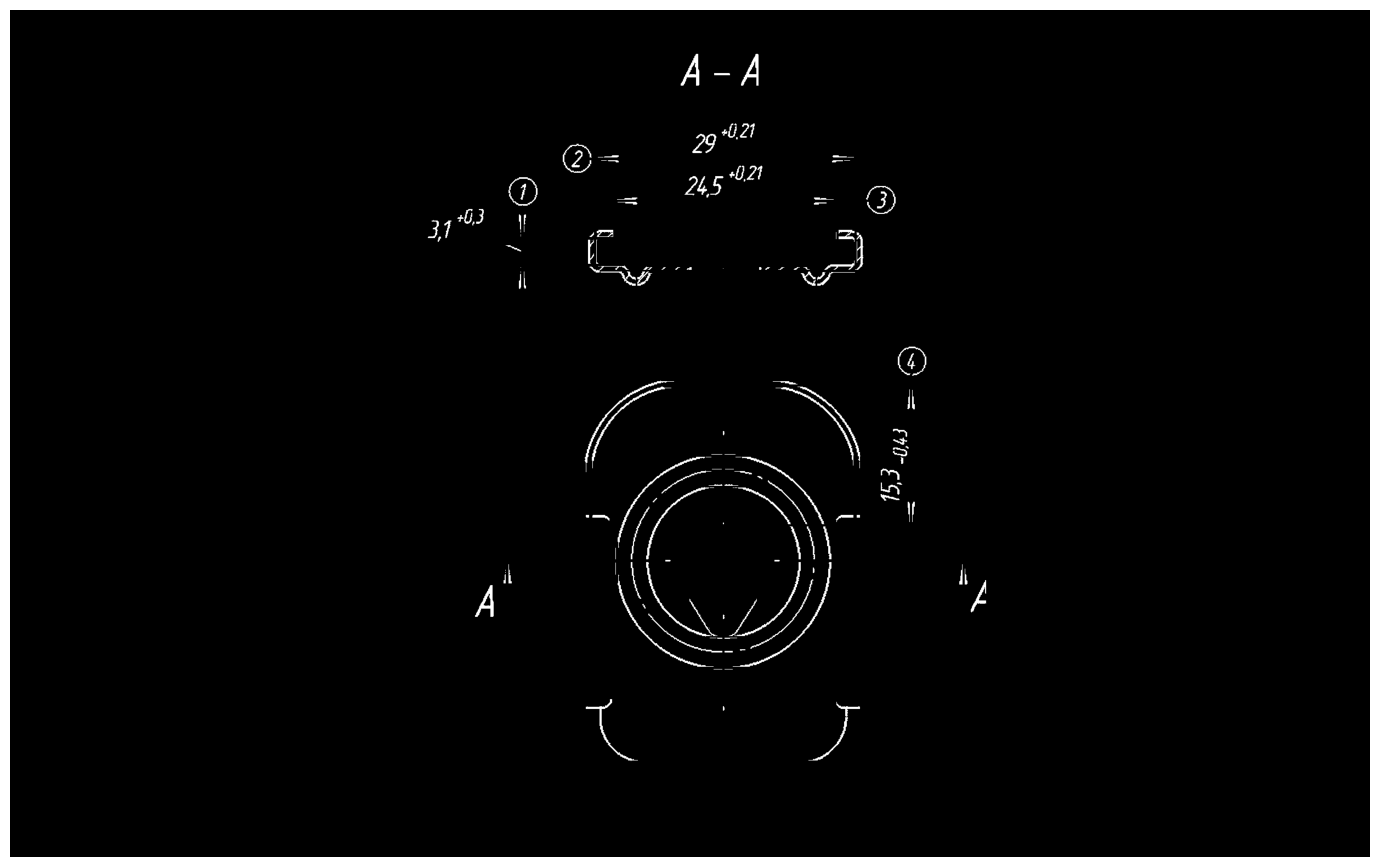

In [27]:
line_length_thresh = 60
kernel_h = cv2.getStructuringElement(cv2.MORPH_RECT, (line_length_thresh, 1))
kernel_v = cv2.getStructuringElement(cv2.MORPH_RECT, (1, line_length_thresh))

# 3. Выделяем только линии с помощью морфологического открытия
horizontal_lines = cv2.morphologyEx(binary_drawing, cv2.MORPH_OPEN, kernel_h)
vertical_lines = cv2.morphologyEx(binary_drawing, cv2.MORPH_OPEN, kernel_v)

# Объединяем найденные линии в одну маску
lines_mask = cv2.bitwise_or(horizontal_lines, vertical_lines)

# Опционально: немного расширяем маску линий, чтобы гарантированно "перерезать"
# места слипания с текстом
dilate_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
lines_mask = cv2.dilate(lines_mask, dilate_kernel, iterations=1)

# 4. Вычитаем линии из исходного бинарного чертежа
binary_no_lines = cv2.subtract(binary_drawing, lines_mask)

plt.figure(figsize=(18, 11))
plt.imshow(binary_no_lines, cmap="gray")
plt.axis("off")
plt.show()

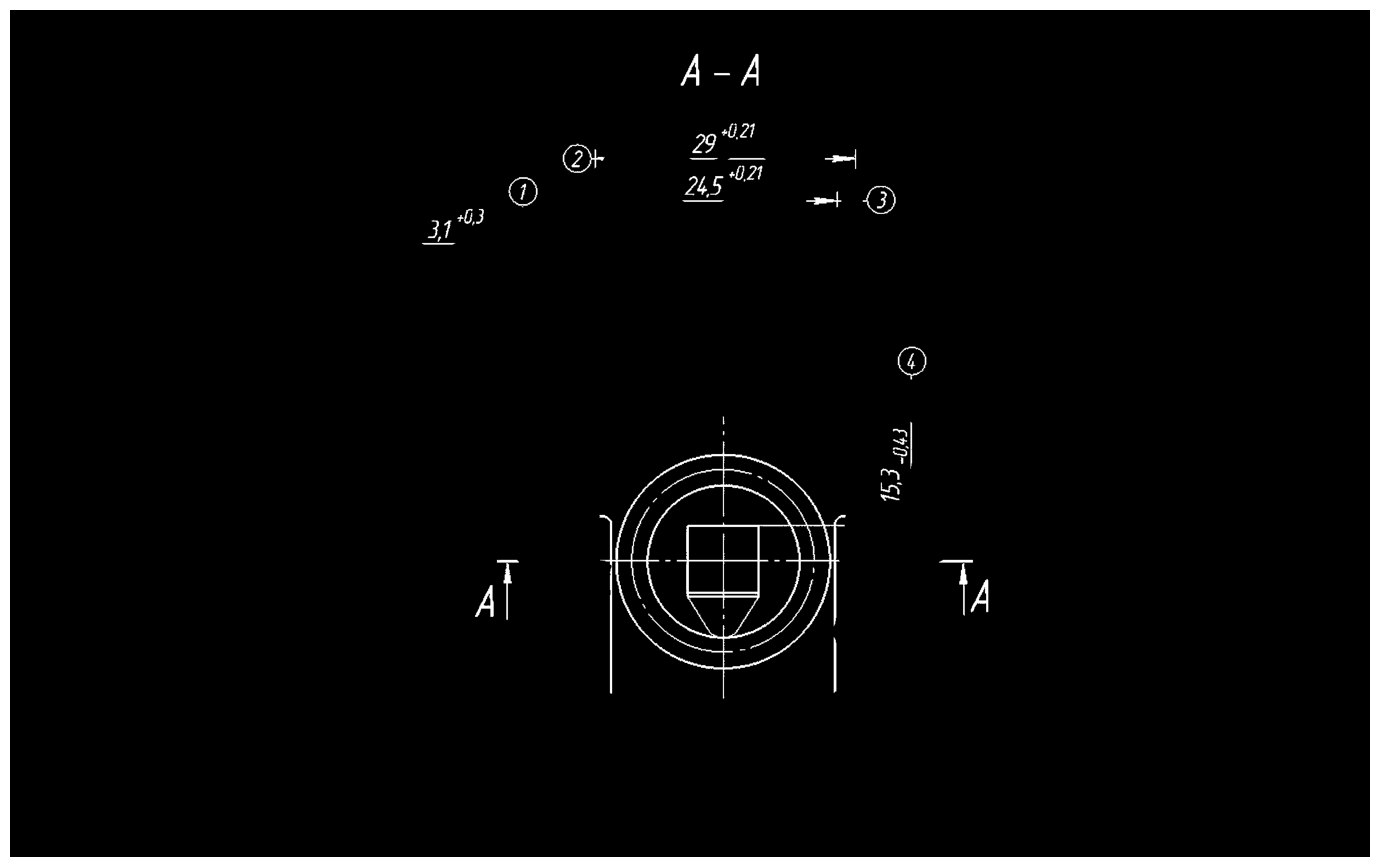

In [28]:
isolated_text_binary = cv2.bitwise_and(binary_drawing, binary_drawing, mask=_geom_mask)

plt.figure(figsize=(18, 11))
plt.imshow(isolated_text_binary, cmap="gray")
plt.axis("off")
plt.show()

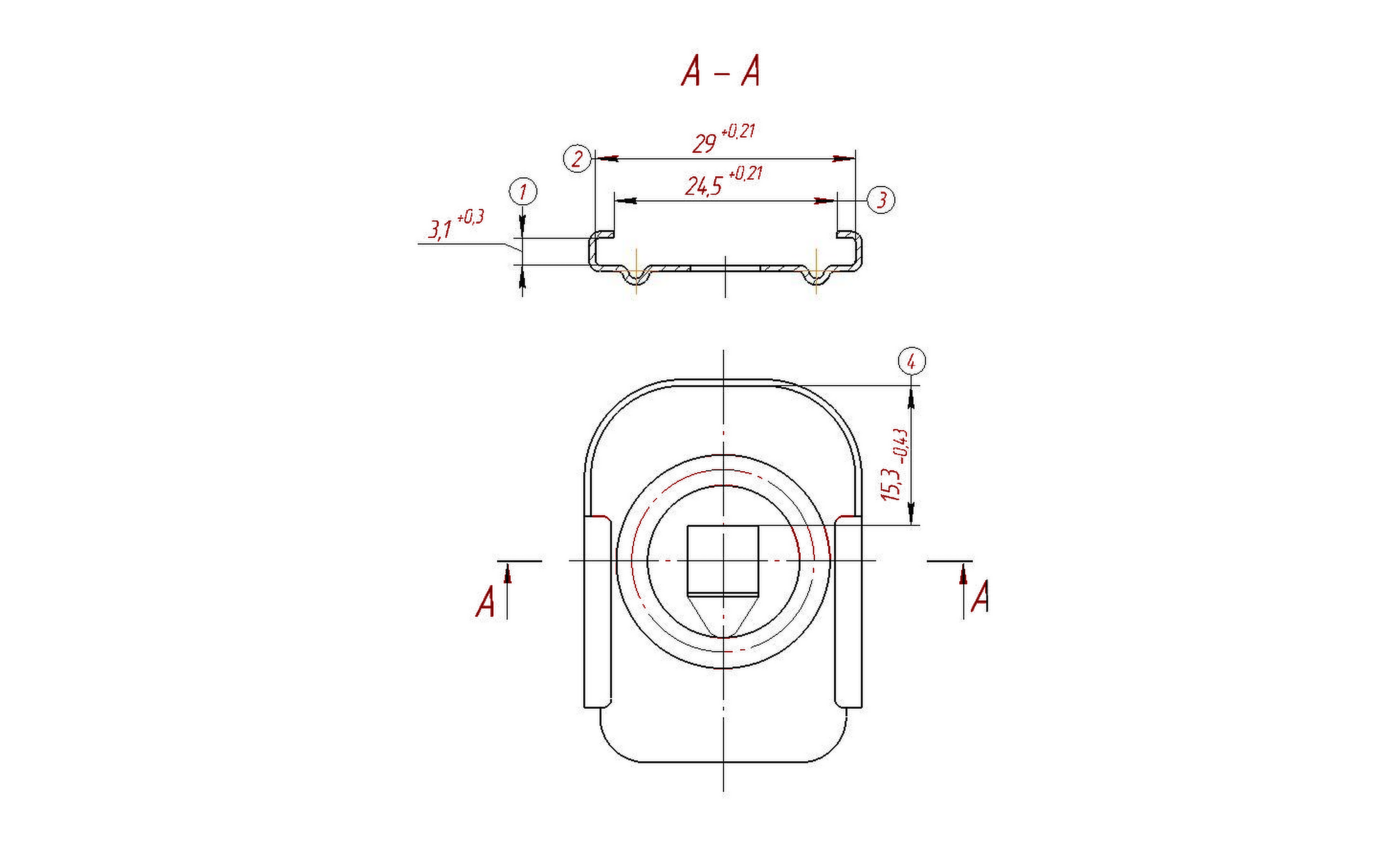

In [29]:
final_text_mask = filter_by_components(
    binary_image=binary_no_lines,
    geom_unclip_mask=_geom_mask,
    max_char_size=50,
)

vis_text = img_300dpi.copy()

vis_text[final_text_mask > 0] = (0, 0, 255)
blend = cv2.addWeighted(vis_text, 0.45, img_300dpi, 0.55, 0)

plt.figure(figsize=(18, 11))
plt.imshow(blend[:, :, ::-1])
plt.axis("off")
plt.show()

In [ ]:
from ipywidgets import FloatSlider, interact

# distanceTransform по бинарному чертежу: для каждого пикселя штриха даёт
# расстояние до ближайшего фонового пикселя ~= половина локальной толщины штриха.
# *2 переводит это в приблизительную толщину линии в пикселях.
dist_map = cv2.distanceTransform(binary_drawing, cv2.DIST_L2, 5)
thickness_map = dist_map * 2

fg_thickness = thickness_map[binary_drawing > 0]
print("thickness_map shape:", thickness_map.shape, "dtype:", thickness_map.dtype)
print("foreground px:", fg_thickness.size)
print("min/max толщина, px:", round(float(fg_thickness.min()), 2), round(float(fg_thickness.max()), 2))
print(
    "percentiles (50/75/90/99):",
    [round(v, 2) for v in np.percentile(fg_thickness, [50, 75, 90, 99])],
)


@interact(thin_threshold_px=FloatSlider(value=3.0, min=0.5, max=15.0, step=0.5))
def preview_thin_thick_split(thin_threshold_px):
    thin_mask = (binary_drawing > 0) & (thickness_map <= thin_threshold_px)
    thick_mask = (binary_drawing > 0) & (thickness_map > thin_threshold_px)

    n_thin = int(thin_mask.sum())
    n_thick = int(thick_mask.sum())
    print(f"thin px: {n_thin}  thick px: {n_thick}  доля thin: {n_thin / (n_thin + n_thick + 1e-9):.3f}")

    vis = np.zeros((*binary_drawing.shape, 3), dtype=np.uint8)
    vis[thin_mask] = (255, 60, 60)  # тонкие линии геометрии — красный
    vis[thick_mask] = (60, 220, 60)  # толстый штрих (крупный текст, заливки) — зелёный

    plt.figure(figsize=(18, 11))
    plt.imshow(vis)
    plt.axis("off")
    plt.title(f"thin <= {thin_threshold_px}px (красный) / thick (зелёный)")
    plt.show()

thickness_map shape: (1545, 2480) dtype: float32
foreground px: 60498
min/max толщина, px: 2.0 12.39
percentiles (50/75/90/99): [np.float64(2.0), np.float64(4.0), np.float64(4.0), np.float64(8.0)]


interactive(children=(FloatSlider(value=3.0, description='thin_threshold_px', max=15.0, min=0.5, step=0.5), Ou…

In [31]:
# ЗАМЕР: одинаковая ли толщина линий у всех чертежей после rescale к 300 dpi.
# Никаких выводов — только цифры. Используем уже проверенный thickness_map = 2 * DT.

rows = []
for i, f in enumerate(files):
    _img = cv2.imread(str(f), cv2.IMREAD_COLOR_BGR)
    src_h, src_w = _img.shape[:2]

    _img300 = rescale_image(_img, 210, 300)
    _gray = cv2.cvtColor(_img300, cv2.COLOR_BGR2GRAY)
    _, _bin = cv2.threshold(_gray, 200, 255, cv2.THRESH_BINARY_INV)

    _thick = cv2.distanceTransform(_bin, cv2.DIST_L2, cv2.DIST_MASK_PRECISE) * 2.0
    _fg = _thick[_bin > 0]

    # Мода: самое частое значение толщины = ширина доминирующей (тонкой) линии
    _hist, _edges = np.histogram(_fg, bins=np.arange(0, 25.25, 0.25))
    _mode = float((_edges[_hist.argmax()] + _edges[_hist.argmax() + 1]) / 2)

    rows.append(
        {
            "idx": i,
            "name": f.stem,
            "src_w": src_w,
            "scale": round(2480 / max(src_w, src_h), 2),
            "fg_px": int(_fg.size),
            "mode": round(_mode, 2),
            "p50": round(float(np.percentile(_fg, 50)), 2),
            "p90": round(float(np.percentile(_fg, 90)), 2),
            "p99": round(float(np.percentile(_fg, 99)), 2),
        }
    )

print(f"{'idx':>3} {'name':>5} {'src_w':>6} {'scale':>6} {'fg_px':>8} {'mode':>6} {'p50':>6} {'p90':>6} {'p99':>6}")
for r in rows:
    print(
        f"{r['idx']:>3} {r['name']:>5} {r['src_w']:>6} {r['scale']:>6} {r['fg_px']:>8} "
        f"{r['mode']:>6} {r['p50']:>6} {r['p90']:>6} {r['p99']:>6}"
    )

_modes = [r["mode"] for r in rows]
print(f"\nмода по датасету: min={min(_modes)}  max={max(_modes)}  уникальных значений={sorted(set(_modes))}")

idx  name  src_w  scale    fg_px   mode    p50    p90    p99
  0     1   1085   2.29   122086   2.12    4.0    8.0  11.31
  1    10   1085   2.29   189179   2.12    4.0    8.0   14.0
  2    11   1421   1.75    60498   2.12    2.0    4.0    8.0
  3    12   1431   1.73    66902   2.12    2.0    4.0    8.0
  4    13   6812   0.36    55515   2.12    2.0    6.0   8.94
  5    14   6819   0.36   201108   2.12    4.0    6.0   8.49
  6    15   1475   1.68   130718   2.12   2.83   5.66   8.94
  7    16   1475   1.68   142319   2.12    2.0   5.66   8.49
  8    17   1085   2.29   218990   2.12   2.83    6.0   10.0
  9    18   4102    0.6   207776   2.12   2.83    8.0   12.0
 10    19   1158   2.14   296657   2.12    4.0    8.0  13.42
 11     2   1085   2.29    95304   2.12    4.0    8.0  17.09
 12    20   9239   0.27   152641   2.12    2.0    4.0    6.0
 13    21   9239   0.27   169367   2.12    2.0    4.0    6.0
 14     3   1085   2.29   121728   2.12    4.0    8.0   12.0
 15     4   1475   1.68 

In [32]:
from skimage.morphology import skeletonize

# ТОТ ЖЕ ЗАМЕР, но толщина снимается только на скелете (гребне штриха),
# где DT = полуширина линии. Цель — проверить, перестанет ли мода быть вырожденной.

rows_skel = []
for i, f in enumerate(files):
    _img = cv2.imread(str(f), cv2.IMREAD_COLOR_BGR)
    src_h, src_w = _img.shape[:2]

    _img300 = rescale_image(_img, 210, 300)
    _gray = cv2.cvtColor(_img300, cv2.COLOR_BGR2GRAY)
    _, _bin = cv2.threshold(_gray, 200, 255, cv2.THRESH_BINARY_INV)

    _dt = cv2.distanceTransform(_bin, cv2.DIST_L2, cv2.DIST_MASK_PRECISE)
    _skel = skeletonize(_bin > 0)
    _t = (_dt * 2.0)[_skel]

    _hist, _edges = np.histogram(_t, bins=np.arange(0, 25.25, 0.25))
    _mode = float((_edges[_hist.argmax()] + _edges[_hist.argmax() + 1]) / 2)

    rows_skel.append(
        {
            "idx": i,
            "name": f.stem,
            "scale": round(2480 / max(src_w, src_h), 2),
            "skel_px": int(_skel.sum()),
            "mode": round(_mode, 2),
            "p50": round(float(np.percentile(_t, 50)), 2),
            "p90": round(float(np.percentile(_t, 90)), 2),
            "p99": round(float(np.percentile(_t, 99)), 2),
        }
    )

print(f"{'idx':>3} {'name':>5} {'scale':>6} {'skel_px':>8} {'mode':>6} {'p50':>6} {'p90':>6} {'p99':>6}")
for r in rows_skel:
    print(
        f"{r['idx']:>3} {r['name']:>5} {r['scale']:>6} {r['skel_px']:>8} "
        f"{r['mode']:>6} {r['p50']:>6} {r['p90']:>6} {r['p99']:>6}"
    )

_m = [r["mode"] for r in rows_skel]
print(f"\nмода по скелету: min={min(_m)}  max={max(_m)}  уникальных={sorted(set(_m))}")

idx  name  scale  skel_px   mode    p50    p90    p99
  0     1   2.29    19667   8.12    8.0    8.0  12.17
  1    10   2.29    33042   4.12   4.47   8.49   16.0
  2    11   1.75    16038   4.12    4.0   5.66    8.0
  3    12   1.73    17615   4.12    4.0   5.66    8.0
  4    13   0.36    15414   2.12    4.0    6.0   10.0
  5    14   0.36    37865   6.12    6.0   7.21   10.0
  6    15   1.68    34944   4.12    4.0    6.0   10.0
  7    16   1.68    38142   4.12    4.0    6.0   10.0
  8    17   2.29    48528   4.12    4.0    8.0   12.0
  9    18    0.6    47341   4.12    4.0    8.0   12.0
 10    19   2.14    57358   4.12   4.47   8.94  14.56
 11     2   2.29    14636   8.12   7.21   8.25  18.44
 12    20   0.27    54033   2.12   2.83    4.0   6.32
 13    21   0.27    62054   2.12   2.83    4.0    6.0
 14     3   2.29    21550   4.12   4.47    8.0  12.17
 15     4   1.68    48522   4.12    4.0    6.0  10.77
 16     5   1.68    55396   6.12    4.0    6.0   10.0
 17     6   2.29    20235   

skeleton px: 16038
толщина min/max: 2.0 12.17
percentiles (10/50/90/99): [np.float64(2.0), np.float64(4.0), np.float64(5.66), np.float64(8.0)]


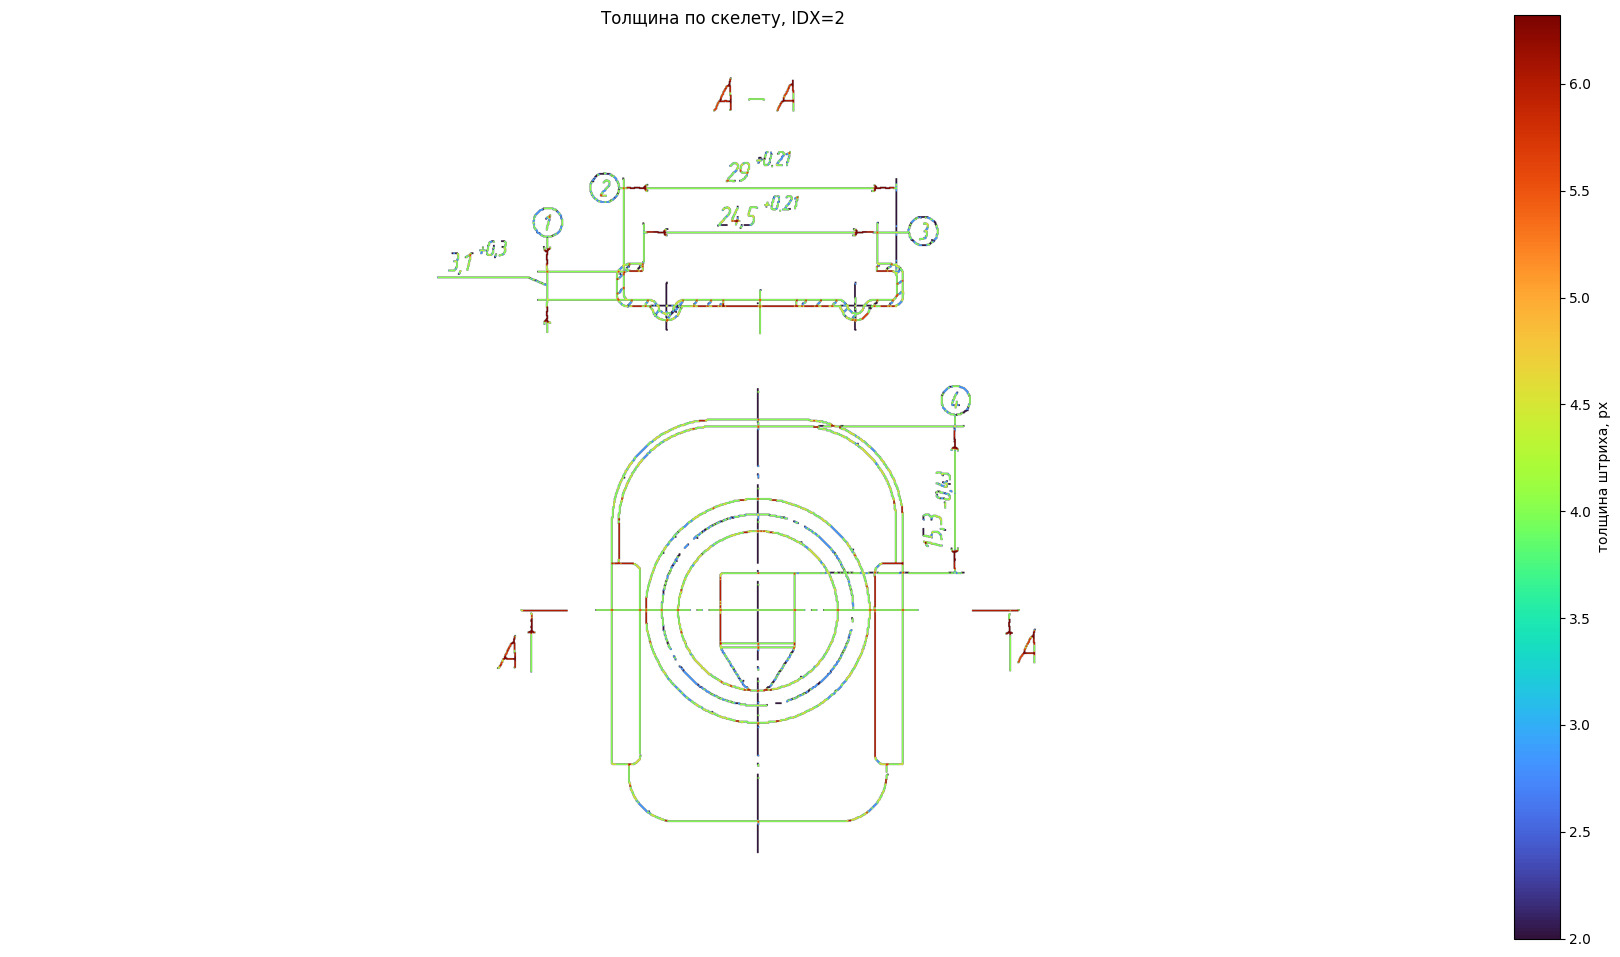

In [33]:
# ДИАГНОСТИКА: раскрашиваем скелет текущего чертежа по толщине штриха.
# Цель — увидеть глазами, отличается ли толщина текста от толщины геометрии.

dt_cur = cv2.distanceTransform(binary_drawing, cv2.DIST_L2, cv2.DIST_MASK_PRECISE)
skel_cur = skeletonize(binary_drawing > 0)
thick_skel_cur = (dt_cur * 2.0) * skel_cur

vals = thick_skel_cur[skel_cur]
print("skeleton px:", int(skel_cur.sum()))
print("толщина min/max:", round(float(vals.min()), 2), round(float(vals.max()), 2))
print("percentiles (10/50/90/99):", [round(v, 2) for v in np.percentile(vals, [10, 50, 90, 99])])

# Утолщаем скелет только для отображения, иначе на 2480px линии не видно
disp = cv2.dilate(thick_skel_cur.astype(np.float32), np.ones((3, 3), np.uint8))
disp = np.ma.masked_where(disp == 0, disp)

plt.figure(figsize=(20, 12))
plt.imshow(disp, cmap="turbo", vmin=float(np.percentile(vals, 2)), vmax=float(np.percentile(vals, 98)))
plt.colorbar(label="толщина штриха, px", fraction=0.03)
plt.axis("off")
plt.title(f"Толщина по скелету, IDX={IDX}")
plt.show()